# Medical Complaint Classification: Training Notebook

**Goal.** Classify a patient's free-text complaint into a predefined **medical category** (for example *Dermatology* or *Respiratory*) and return the **top-3 most likely categories with a probability for each**.

> **Important.** This is an educational project. It classifies text into categories. It is **not** a diagnosis system, **not** emergency triage, and **not** clinically validated.

**Pipeline**

```
Raw complaint -> cleaning -> TF-IDF -> Logistic Regression -> top-3 categories (+ probabilities)
```

**Notebook map**

| # | Section | # | Section |
|---|---|---|---|
| 1 | Setup | 9 | Train the model (TF-IDF + Logistic Regression) |
| 2 | Load the dataset | 10 | Evaluate on the test set |
| 3 | Inspect the dataset | 11 | Optional: Linear SVM comparison |
| 4 | Clean the text | 12 | Error analysis |
| 5 | Map diseases to categories | 13 | Explainability: top words per category |
| 6 | Exploratory data analysis | 14 | Demo predictions |
| 7 | Train/test split | 15 | Save the model |
| 8 | Baseline | 16 | Conclusions and limitations |

**Dataset.** Symptom2Disease-style data (patient symptom descriptions labeled with a disease). Hugging Face: <https://huggingface.co/datasets/gretelai/symptom_to_diagnosis>. Kaggle version: <https://www.kaggle.com/datasets/niyarrbarman/symptom2disease>.

**How to run.** `Kernel -> Restart & Run All`. The first run needs internet to download the data (or put the files in `data/` yourself, see README).

## 1. Setup

We import the libraries and define a few constants in one place so they are easy to find and change.

- `RANDOM_STATE` makes the results reproducible (same split, same model every run).
- `TOP_K = 3` is the number of categories shown in the final prediction.
- `MIN_CLASS_SIZE` protects us from categories that are too small to learn from.

In [2]:
import json
import re
import urllib.request
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

# ---- Constants -----------------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_K = 3
MIN_CLASS_SIZE = 30          # categories with fewer examples are merged into "Other"

# ---- Paths (works whether Jupyter starts in the project root or in notebooks/) ---
ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
for folder in (DATA_DIR, PROCESSED_DIR, MODELS_DIR, REPORTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("scikit-learn version:", sklearn.__version__)
print("Project root:", ROOT.resolve())

scikit-learn version: 1.9.1
Project root: C:\Users\toufi\Pictures\medical-complaint-classifier


## 2. Load the dataset

The code looks for `.jsonl` or `.csv` files inside `data/`. If none are found, it downloads the two files of the Hugging Face dataset `gretelai/symptom_to_diagnosis` (`train.jsonl` and `test.jsonl`).

Dataset versions use different column names (for example `input_text`/`output_text` on Hugging Face and `text`/`label` on Kaggle). So instead of hard-coding names, we **detect** them:

- the **text column** is the text column with the longest average length (sentences are longer than labels);
- the **label column** is the other text column with the fewest distinct values.

The detected names are printed so you can verify them. Every file is renamed to the same two columns, `text` and `disease`.

> The provided train/test files are **merged** here and re-split later with our own stratified 80/20 split. That way the split follows the project specification and the duplicate check covers all rows at once.

In [3]:
HF_BASE = "https://huggingface.co/datasets/gretelai/symptom_to_diagnosis/resolve/main/"
HF_FILES = ["train.jsonl", "test.jsonl"]


def ensure_data_files():
    """Return local data files; download the Hugging Face files if the folder is empty."""
    found = sorted(DATA_DIR.glob("*.jsonl")) + sorted(DATA_DIR.glob("*.csv"))
    if found:
        return found
    print("No local data found in data/ -> downloading from Hugging Face ...")
    for name in HF_FILES:
        try:
            urllib.request.urlretrieve(HF_BASE + name, DATA_DIR / name)
            print("  downloaded:", name)
        except Exception as error:
            print(f"  FAILED to download {name}: {error}")
    found = sorted(DATA_DIR.glob("*.jsonl")) + sorted(DATA_DIR.glob("*.csv"))
    if not found:
        raise FileNotFoundError(
            "Could not download the dataset. Download it manually (see README, section 'Dataset') "
            "and place the .jsonl/.csv files in the data/ folder, then re-run this cell."
        )
    return found


def load_file(path):
    """Read one file and return a DataFrame with the columns: text, disease, source."""
    df = pd.read_json(path, lines=True) if path.suffix == ".jsonl" else pd.read_csv(path)
    string_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]
    avg_len = {c: df[c].dropna().astype(str).str.len().mean() for c in string_cols}
    text_col = max(avg_len, key=avg_len.get)
    label_col = min((c for c in string_cols if c != text_col), key=lambda c: df[c].nunique())
    print(f"{path.name}: {len(df)} rows | columns = {list(df.columns)} | text = '{text_col}' | label = '{label_col}'")
    out = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "disease"})
    out["source"] = path.name
    return out


data_files = ensure_data_files()
raw = pd.concat([load_file(p) for p in data_files], ignore_index=True)
print("\nCombined raw dataset:", raw.shape)
display(raw.head())

No local data found in data/ -> downloading from Hugging Face ...
  downloaded: train.jsonl
  downloaded: test.jsonl
test.jsonl: 212 rows | columns = ['output_text', 'input_text'] | text = 'input_text' | label = 'output_text'
train.jsonl: 853 rows | columns = ['output_text', 'input_text'] | text = 'input_text' | label = 'output_text'

Combined raw dataset: (1065, 3)


,text,disease,source
0,I have a burning sensation in my stomach that comes and goes. It's worse when I eat and when I lie down. I also have...,peptic ulcer disease,test.jsonl
1,I have a hard time swallowing and I feel like food is getting stuck in my throat. I belch a lot and feel bloated. I ...,peptic ulcer disease,test.jsonl
2,"I've been having headaches and migraines, and I can't sleep. My whole body shakes and twitches. Sometimes I feel lig...",drug reaction,test.jsonl
3,I'm sweating a lot and can't catch my breath. My throat is full of phlegm and I feel awful. My heart is racing and m...,pneumonia,test.jsonl
4,"I've been scratching myself a lot lately, and my skin is covered in rashy places. I also have a few pimples that are...",fungal infection,test.jsonl


## 3. Inspect the dataset

The project specification says: **do not choose a dataset only because its name sounds suitable.** We therefore answer the 11 checklist questions with real numbers before doing anything else.

In [4]:
def normalise_for_dupes(s):
    return re.sub(r"[^a-z0-9 ]", "", str(s).lower()).strip()


print("1. Number of rows:", len(raw))
print("2. Columns:", list(raw.columns))
print("3. Text column  -> 'text'")
print("4. Label column -> 'disease'")
print("5. Number of distinct disease labels:", raw["disease"].nunique())
print("\n6. Distribution of labels:")
display(raw["disease"].value_counts())

print("7. Missing values per column:")
display(raw.isna().sum())

n_exact = raw.duplicated(subset=["text"]).sum()
n_near = raw["text"].map(normalise_for_dupes).duplicated().sum()
conflicts = raw.groupby("text")["disease"].nunique()
print(f"8. Duplicates -> exact duplicate texts: {n_exact} | duplicates after ignoring punctuation/case: {n_near}")
print(f"   Texts that appear with MORE THAN ONE label: {(conflicts > 1).sum()}")

print("\n9/10/11. Do the texts look like complaints, and do the labels make sense? Read 8 random samples:")
for _, row in raw.sample(8, random_state=RANDOM_STATE).iterrows():
    print(f"  [{row['disease']}]  {row['text'][:200]}")

words = raw["text"].dropna().astype(str).str.split().str.len()
print("\nText length in words:")
display(words.describe().round(1))

1. Number of rows: 1065
2. Columns: ['text', 'disease', 'source']
3. Text column  -> 'text'
4. Label column -> 'disease'
5. Number of distinct disease labels: 22

6. Distribution of labels:


disease
cervical spondylosis               50
psoriasis                          50
arthritis                          50
malaria                            50
bronchial asthma                   50
diabetes                           50
chicken pox                        50
impetigo                           50
hypertension                       50
dengue                             50
varicose veins                     50
allergy                            50
gastroesophageal reflux disease    49
common cold                        49
drug reaction                      48
fungal infection                   48
urinary tract infection            48
peptic ulcer disease               47
pneumonia                          47
typhoid                            47
migraine                           42
jaundice                           40
Name: count, dtype: int64

7. Missing values per column:


text       0
disease    0
source     0
dtype: int64

8. Duplicates -> exact duplicate texts: 5 | duplicates after ignoring punctuation/case: 5
   Texts that appear with MORE THAN ONE label: 0

9/10/11. Do the texts look like complaints, and do the labels make sense? Read 8 random samples:
  [cervical spondylosis]  I've been having neck pain, instability, and balance concerns.
  [dengue]  I have rashes on my skin, which itch when I touch them. My joints pain all day and I don't feel good. At night, I have mild fever and get chills, which makes it difficult for me to sleep.
  [dengue]  I have red spots on my body that are itchy and inflamed. I also have a high fever and chills.
  [pneumonia]  I've been feeling really sick lately. I've been coughing a lot, and I've been having trouble breathing. I've also been having chills and a fever. I've been feeling really weak and tired. I've also bee
  [peptic ulcer disease]  I've been losing weight and can't seem to gain it back. I use antacids to help with the pain and discomfort I feel. My mouth f

count    1065.0
mean       28.9
std         7.5
min         7.0
25%        24.0
50%        28.0
75%        34.0
max        59.0
Name: text, dtype: float64

### Inspection conclusions *(fill in after running the cell above)*

- Rows: ...
- Number of diseases: ... (balanced / imbalanced?)
- Duplicates found: ...
- Do the texts read like patient complaints? ...
- Are the labels meaningful? ...
- Verdict: usable / not usable because ...

*Example of what to write:* "The dataset has N rows and K diseases with roughly equal class sizes. Texts are short first-person symptom descriptions. Labels are disease names, so we map them to medical categories (section 5). The data is small and probably synthetic or not clinically validated, which we list as a limitation."

## 4. Clean the text

Cleaning is **simple and conservative** on purpose:

1. drop rows with missing text or label;
2. lowercase everything;
3. remove unusual characters (keep letters, digits, spaces and basic punctuation);
4. collapse repeated whitespace;
5. drop exact duplicate rows.

We deliberately do **not** remove stop-words. Words such as **no**, **not** and **without** change the meaning of a medical sentence ("chest pain" is not the same as "no chest pain"), and TF-IDF with word pairs (bigrams) can still use them.

The *same* `clean_text` function is copied into `app.py` and `main.py`, so training and prediction treat text identically.

In [5]:
def clean_text(text):
    """Conservative cleaning (keep identical to app.py and main.py)."""
    text = str(text).lower()
    text = re.sub(r"[^\w\s.,'\-/%]", " ", text)   # remove unusual characters
    text = re.sub(r"\s+", " ", text).strip()       # collapse whitespace
    return text


df = raw.copy()
n_start = len(df)

df = df.dropna(subset=["text", "disease"])
df["text"] = df["text"].map(clean_text)
df["disease"] = df["disease"].astype(str).str.strip().str.lower()
df = df[df["text"].str.len() > 0]
n_after_missing = len(df)

df = df.drop_duplicates(subset=["text", "disease"]).reset_index(drop=True)

print(f"Rows at start:                 {n_start}")
print(f"Rows after dropping missing:   {n_after_missing}  (removed {n_start - n_after_missing})")
print(f"Rows after dropping duplicates: {len(df)}  (removed {n_after_missing - len(df)})")
display(df[["text", "disease"]].head())

Rows at start:                 1065
Rows after dropping missing:   1065  (removed 0)
Rows after dropping duplicates: 1060  (removed 5)


,text,disease
0,i have a burning sensation in my stomach that comes and goes. it's worse when i eat and when i lie down. i also have...,peptic ulcer disease
1,i have a hard time swallowing and i feel like food is getting stuck in my throat. i belch a lot and feel bloated. i ...,peptic ulcer disease
2,"i've been having headaches and migraines, and i can't sleep. my whole body shakes and twitches. sometimes i feel lig...",drug reaction
3,i'm sweating a lot and can't catch my breath. my throat is full of phlegm and i feel awful. my heart is racing and m...,pneumonia
4,"i've been scratching myself a lot lately, and my skin is covered in rashy places. i also have a few pimples that are...",fungal infection


## 5. Map diseases to medical categories

The dataset labels each text with a **disease**, but this project predicts a **medical category** (specialty). This is deliberate: predicting one of ~10 categories needs far less data than predicting one of dozens of diseases, and it is the goal in the project specification.

We create the category label with **one explicit dictionary**. Rules:

- every disease must map to exactly one category (the code stops with a clear message if one is missing);
- some cases are judgment calls (e.g. *chicken pox* could be Dermatology or Infectious Disease; *drug reaction* could be Allergy or Dermatology). We choose one and **document it as a limitation**;
- this mapping is **not clinically validated**;
- if a disease name in your dataset version is missing, just add one line to the dictionary.

In [6]:
CATEGORY_MAP = {
    # Dermatology
    "psoriasis": "Dermatology",
    "impetigo": "Dermatology",
    "fungal infection": "Dermatology",
    "acne": "Dermatology",
    # Infectious Disease
    "dengue": "Infectious Disease",
    "malaria": "Infectious Disease",
    "typhoid": "Infectious Disease",
    "chicken pox": "Infectious Disease",
    "chickenpox": "Infectious Disease",
    # Respiratory
    "pneumonia": "Respiratory",
    "bronchial asthma": "Respiratory",
    "common cold": "Respiratory",
    # Gastroenterology
    "gastroesophageal reflux disease": "Gastroenterology",
    "gerd": "Gastroenterology",
    "peptic ulcer disease": "Gastroenterology",
    "jaundice": "Gastroenterology",
    "dimorphic hemorrhoids(piles)": "Gastroenterology",
    "dimorphic hemorrhoids": "Gastroenterology",
    # Cardiovascular
    "hypertension": "Cardiovascular",
    "varicose veins": "Cardiovascular",
    # Neurology
    "migraine": "Neurology",
    # Musculoskeletal
    "arthritis": "Musculoskeletal",
    "cervical spondylosis": "Musculoskeletal",
    # Endocrinology
    "diabetes": "Endocrinology",
    # Urology
    "urinary tract infection": "Urology",
    # Allergy
    "allergy": "Allergy",
    "drug reaction": "Allergy",
}

df["category"] = df["disease"].map(CATEGORY_MAP)

unmapped = sorted(df.loc[df["category"].isna(), "disease"].unique())
if unmapped:
    raise ValueError(
        f"These diseases have no category yet: {unmapped}\n"
        "Add them to CATEGORY_MAP above (one line each) and re-run this cell."
    )
print("All diseases are mapped. Rows:", len(df))

# --- Consistency after mapping -------------------------------------------------
# A text that appears under two DIFFERENT categories is ambiguous -> remove it.
# Remaining repeated texts (same category) are duplicates -> keep one copy.
n_cat = df.groupby("text")["category"].nunique()
conflict_texts = n_cat[n_cat > 1].index
df = df[~df["text"].isin(conflict_texts)]
n_before = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print(f"Removed {len(conflict_texts)} ambiguous texts and {n_before - len(df)} duplicate texts. Rows left: {len(df)}")

# --- Merge categories that are too small to learn from --------------------------
counts = df["category"].value_counts()
small = counts[counts < MIN_CLASS_SIZE].index.tolist()
if small:
    print("Merging small categories into 'Other':", small)
    df.loc[df["category"].isin(small), "category"] = "Other"

print("\nFinal mapping (category -> diseases):")
display(df.groupby("category")["disease"].unique().to_frame("diseases"))

df.to_csv(PROCESSED_DIR / "complaints_clean.csv", index=False)
print("Saved:", PROCESSED_DIR / "complaints_clean.csv")

All diseases are mapped. Rows: 1060
Removed 0 ambiguous texts and 0 duplicate texts. Rows left: 1060

Final mapping (category -> diseases):


,diseases
category,
Allergy,"[drug reaction, allergy]"
Cardiovascular,"[hypertension, varicose veins]"
Dermatology,"[fungal infection, psoriasis, impetigo]"
Endocrinology,[diabetes]
Gastroenterology,"[peptic ulcer disease, gastroesophageal reflux disease, jaundice]"
Infectious Disease,"[malaria, typhoid, chicken pox, dengue]"
Musculoskeletal,"[cervical spondylosis, arthritis]"
Neurology,[migraine]
Respiratory,"[pneumonia, bronchial asthma, common cold]"


Saved: ..\data\processed\complaints_clean.csv


## 6. Exploratory data analysis (EDA)

Kept short and useful: dataset size, number of categories, class distribution (bar chart), and text length. If the classes are imbalanced, we mention it in the report and compensate during training with `class_weight="balanced"`.

Dataset size: 1060 rows
Categories: 10
Missing values: 0


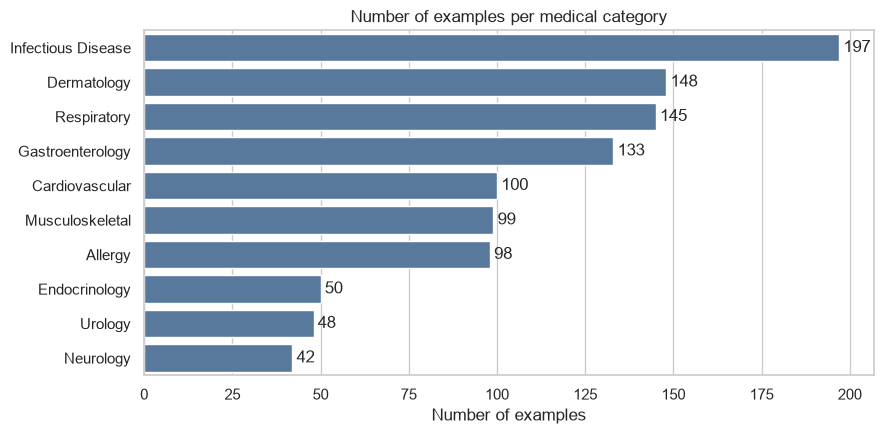

Largest / smallest category ratio: 4.7x  -> imbalanced (we use class_weight='balanced')


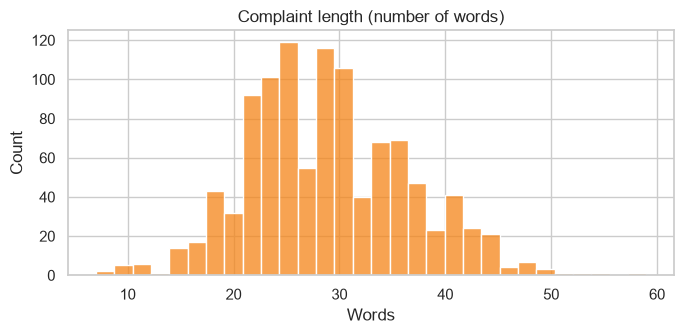

,words
count,1060.0
mean,28.9
std,7.5
min,7.0
25%,24.0
50%,28.0
75%,34.0
max,59.0


In [7]:
print("Dataset size:", len(df), "rows")
print("Categories:", df["category"].nunique())
print("Missing values:", int(df[["text", "category"]].isna().sum().sum()))

order = df["category"].value_counts().index
plt.figure(figsize=(9, 4.5))
ax = sns.countplot(data=df, y="category", order=order, color="#4C78A8")
ax.bar_label(ax.containers[0], padding=3)
plt.title("Number of examples per medical category")
plt.xlabel("Number of examples")
plt.ylabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_distribution.png", dpi=150)
plt.show()

ratio = df["category"].value_counts().max() / df["category"].value_counts().min()
print(f"Largest / smallest category ratio: {ratio:.1f}x  ->",
      "imbalanced (we use class_weight='balanced')" if ratio > 1.5 else "fairly balanced")

df["n_words"] = df["text"].str.split().str.len()
plt.figure(figsize=(7, 3.5))
sns.histplot(df["n_words"], bins=30, color="#F58518")
plt.title("Complaint length (number of words)")
plt.xlabel("Words")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "text_length.png", dpi=150)
plt.show()
display(df["n_words"].describe().round(1).to_frame("words"))

## 7. Train/test split

We split **80% training / 20% testing** with `stratify=y`, so every category appears in both sets with the same proportion. The test set is **never** used for fitting or tuning; it is only used once at the end to measure performance.

**Avoiding data leakage.** TF-IDF learns a vocabulary and word weights. If it were fitted on all the data, information from the test set would leak into training. We avoid this by putting TF-IDF *inside* a scikit-learn `Pipeline`: when the pipeline is fitted, TF-IDF sees the training texts only, and the test texts are only transformed.

In [8]:
X = df["text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
display(pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}))

Train: 848 rows | Test: 212 rows


,train,test
category,,
Allergy,78,20
Cardiovascular,80,20
Dermatology,118,30
Endocrinology,40,10
Gastroenterology,107,26
Infectious Disease,158,39
Musculoskeletal,79,20
Neurology,34,8
Respiratory,116,29


## 8. Baseline

Before judging our model we need a reference point. The baseline always predicts the most frequent category. Any useful model must clearly beat it.

In [9]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_base = baseline.predict(X_test)
baseline_acc = accuracy_score(y_test, pred_base)
baseline_f1 = f1_score(y_test, pred_base, average="macro")
print(f"Baseline accuracy: {baseline_acc:.3f} | Baseline macro-F1: {baseline_f1:.3f}")

Baseline accuracy: 0.184 | Baseline macro-F1: 0.031


## 9. Train the model: TF-IDF + Logistic Regression

**TF-IDF** (Term Frequency - Inverse Document Frequency) turns each text into a vector of numbers. A word gets a high weight when it appears often in *this* complaint but rarely in *other* complaints, so words like "itching" matter more than words like "have". We use `ngram_range=(1, 2)` to include word pairs, which helps with phrases like "chest pain" or "no cough".

**Logistic Regression** learns, for every category, which words push a text towards that category, and outputs a **probability for every category**. Those probabilities are what let us show the top-3.

**Tuning.** We try a few values of `C` (regularisation strength) and of `ngram_range` with 5-fold cross-validation **on the training set only**, choosing the best macro-F1. `class_weight="balanced"` gives small categories a fair weight.

In [10]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, sublinear_tf=True)),   # no stop-word removal on purpose
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [1, 5, 10, 20],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best parameters:", grid.best_params_)
print(f"Cross-validated macro-F1 on the TRAIN set: {grid.best_score_:.3f}")

Best parameters: {'clf__C': 10, 'tfidf__ngram_range': (1, 1)}
Cross-validated macro-F1 on the TRAIN set: 0.964


## 10. Evaluate on the test set

Accuracy alone can be misleading, so we report:

- **Accuracy**: share of correct predictions.
- **Precision**: when the model says "Dermatology", how often is it right?
- **Recall**: of all real Dermatology complaints, how many did the model find?
- **F1-score**: balance between precision and recall. **Macro-F1** averages F1 over categories (every category counts equally).
- **Confusion matrix**: which categories get confused with which.
- **Top-3 accuracy**: the correct category is among the 3 shown. This matches how the app displays results.

,Accuracy,Macro-F1,Top-3 accuracy
Baseline (most frequent),0.184,0.031,NaN
TF-IDF + Logistic Regression,0.958,0.951,0.991



Per-category report:
                    precision    recall  f1-score   support

           Allergy      0.882     0.750     0.811        20
    Cardiovascular      1.000     1.000     1.000        20
       Dermatology      0.968     1.000     0.984        30
     Endocrinology      0.900     0.900     0.900        10
  Gastroenterology      0.963     1.000     0.981        26
Infectious Disease      0.974     0.974     0.974        39
   Musculoskeletal      0.952     1.000     0.976        20
         Neurology      1.000     0.875     0.933         8
       Respiratory      0.933     0.966     0.949        29
           Urology      1.000     1.000     1.000        10

          accuracy                          0.958       212
         macro avg      0.957     0.946     0.951       212
      weighted avg      0.957     0.958     0.956       212



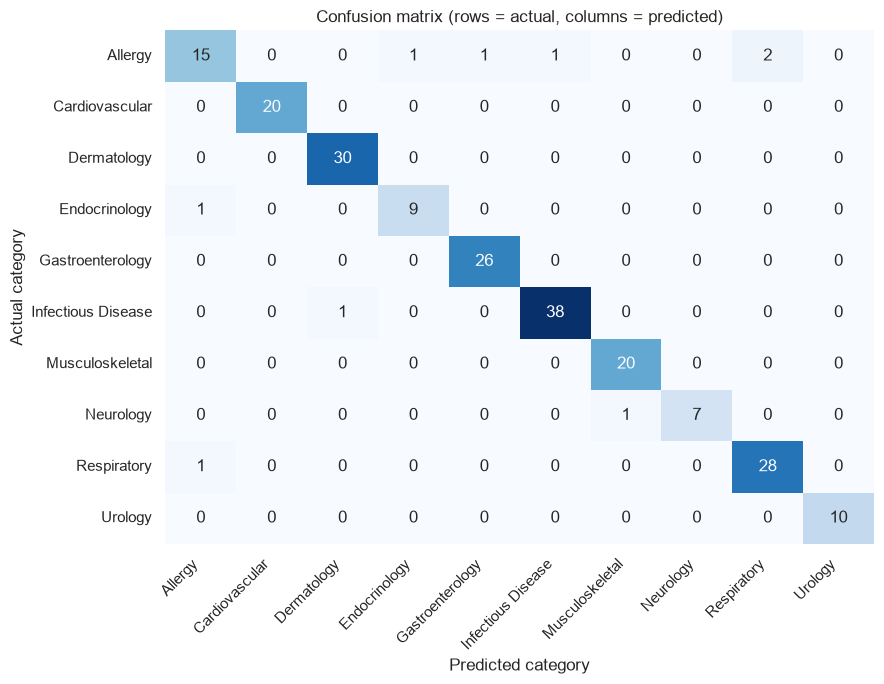

In [11]:
def top_k_accuracy(estimator, X_data, y_true, k=3):
    """Share of samples whose true category is among the k most probable categories."""
    proba = estimator.predict_proba(X_data)
    top_idx = np.argsort(proba, axis=1)[:, -k:]
    classes = estimator.classes_
    return float(np.mean([truth in classes[idx] for truth, idx in zip(np.asarray(y_true), top_idx)]))


pred = model.predict(X_test)
acc = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average="macro")
top3 = top_k_accuracy(model, X_test, y_test, k=TOP_K)

summary = pd.DataFrame({
    "Accuracy": [baseline_acc, acc],
    "Macro-F1": [baseline_f1, macro_f1],
    f"Top-{TOP_K} accuracy": [np.nan, top3],
}, index=["Baseline (most frequent)", "TF-IDF + Logistic Regression"])
display(summary.round(3))

print("\nPer-category report:")
print(classification_report(y_test, pred, digits=3))

labels = model.classes_
cm = confusion_matrix(y_test, pred, labels=labels)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False)
plt.title("Confusion matrix (rows = actual, columns = predicted)")
plt.xlabel("Predicted category")
plt.ylabel("Actual category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 11. Optional: Linear SVM comparison

The specification allows **one** comparison model: Linear SVM, which is also a natural fit for sparse TF-IDF features. We reuse the best TF-IDF settings found above. A Linear SVM has no probabilities, so its top-3 uses its decision scores (enough for comparing). We keep **Logistic Regression** for the app because it gives real probability scores.

In [12]:
best_ngram = grid.best_params_["tfidf__ngram_range"]
svm = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, sublinear_tf=True, ngram_range=best_ngram)),
    ("clf", LinearSVC(class_weight="balanced", C=1.0, random_state=RANDOM_STATE)),
])
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

svm_scores = svm.decision_function(X_test)
svm_top = np.argsort(svm_scores, axis=1)[:, -TOP_K:]
svm_top3 = float(np.mean([t in svm.classes_[idx] for t, idx in zip(np.asarray(y_test), svm_top)]))

comparison = pd.DataFrame({
    "Accuracy": [acc, accuracy_score(y_test, svm_pred)],
    "Macro-F1": [macro_f1, f1_score(y_test, svm_pred, average="macro")],
    f"Top-{TOP_K} accuracy": [top3, svm_top3],
}, index=["Logistic Regression", "Linear SVM"])
display(comparison.round(3))

,Accuracy,Macro-F1,Top-3 accuracy
Logistic Regression,0.958,0.951,0.991
Linear SVM,0.953,0.946,0.991


## 12. Error analysis

Numbers tell us *how often* the model is wrong; looking at examples tells us *why*. Below we list wrong predictions with the model's top-3, and count the most frequent confusions. Typical reasons: two categories share symptoms (e.g. Respiratory vs Infectious Disease: fever and cough), a vague text, or a judgment-call label in our mapping.

In [13]:
proba_test = model.predict_proba(X_test)
top3_labels = [
    ", ".join(f"{model.classes_[i]} {proba_test[r, i]:.0%}" for i in np.argsort(proba_test[r])[::-1][:TOP_K])
    for r in range(len(X_test))
]

results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": pred,
    "top3": top3_labels,
})
errors = results[results["actual"] != results["predicted"]]

print(f"Misclassified: {len(errors)} of {len(results)} test examples ({len(errors) / len(results):.1%})")
if len(errors):
    print("\nMost frequent confusions (actual -> predicted):")
    display(errors.groupby(["actual", "predicted"]).size().sort_values(ascending=False).head(8).to_frame("count"))
    print("Examples:")
    display(errors.head(12).reset_index(drop=True))
else:
    print("No errors on this test split. With a small, clean dataset this is possible; discuss it as a limitation.")

Misclassified: 9 of 212 test examples (4.2%)

Most frequent confusions (actual -> predicted):


count
actual             predicted                
Allergy            Respiratory             2
                   Endocrinology           1
                   Gastroenterology        1
                   Infectious Disease      1
Endocrinology      Allergy                 1
Infectious Disease Dermatology             1
Neurology          Musculoskeletal         1
Respiratory        Allergy                 1

Examples:


,text,actual,predicted,top3
0,"i'm not interested in sex anymore, and it's hard for me to get aroused. i also have brain fog and feel confused a lot.",Allergy,Endocrinology,"Endocrinology 37%, Allergy 29%, Gastroenterology 9%"
1,"i've been having trouble swallowing, and my throat is sore. my nose has been running, and i've been sneezing a lot.",Allergy,Respiratory,"Respiratory 54%, Allergy 34%, Gastroenterology 2%"
2,"i have a stiff neck and eye issues, and i've been hungry all the time.",Neurology,Musculoskeletal,"Musculoskeletal 31%, Endocrinology 22%, Allergy 13%"
3,i've been feeling sick for a few days. i have a sore throat and my nose is running. i've also been having trouble sw...,Allergy,Respiratory,"Respiratory 72%, Allergy 9%, Cardiovascular 6%"
4,i have a lot of pain in my chest and i feel really sick to my stomach. my chest has been hurting a lot lately and i'...,Allergy,Gastroenterology,"Gastroenterology 42%, Allergy 21%, Infectious Disease 10%"
5,i have been suffering from dry cough and difficulty in breathing for a week now. i also feel weak throughout the day.,Respiratory,Allergy,"Allergy 26%, Infectious Disease 19%, Respiratory 19%"
6,"i have a rash on my skin that is red, itchy, and painful. it is spreading all over my body.",Infectious Disease,Dermatology,"Dermatology 81%, Infectious Disease 17%, Cardiovascular 1%"
7,i have been feeling very sick lately. i have been having chest pain and i feel very nauseous. i also sweat a lot.,Allergy,Infectious Disease,"Infectious Disease 22%, Gastroenterology 16%, Endocrinology 13%"
8,i feel weak and tired. i can't taste or smell things as well as i used to. sometimes my heart beats fast or i feel l...,Endocrinology,Allergy,"Allergy 57%, Endocrinology 20%, Respiratory 5%"


### Error analysis notes *(fill in after running)*

- Which categories are confused most often? ...
- Is the confusion medically plausible (shared symptoms)? ...
- Are the wrong texts vague or short? ...
- Could the labeling/mapping choice explain some errors? ...

## 13. Explainability: top words per category

Because the model is linear, we can read which words (or word pairs) push a text most strongly towards each category. This is a big advantage of the classical approach: it can be explained, and it helps us check that the model learned sensible medical vocabulary instead of accidental patterns.

In [14]:
vectorizer = model.named_steps["tfidf"]
classifier = model.named_steps["clf"]
terms = np.array(vectorizer.get_feature_names_out())

rows = []
for i, category in enumerate(classifier.classes_):
    top_terms = terms[np.argsort(classifier.coef_[i])[-8:][::-1]]
    rows.append({"category": category, "top terms": ", ".join(top_terms)})
display(pd.DataFrame(rows))

,category,top terms
0,Allergy,"sometimes, dry, shiver, eyes, remembering, everything, chest, medication"
1,Cardiovascular,"legs, chest, veins, dizziness, calves, cramps, dizzy, headache"
2,Dermatology,"on, sores, rash, skin, face, nails, nose, peeling"
3,Endocrinology,"thirsty, infections, hungry, always, palpitations, healing, confused, heal"
4,Gastroenterology,"yellow, stomach, weight, heartburn, after, turned, eat, mouth"
5,Infectious Disease,"vomiting, fever, headache, spots, chills, really, appetite, arms"
6,Musculoskeletal,"neck, joints, back, pain, weakness, stiff, balance, around"
7,Neurology,"vision, headaches, they, side, blurred, distorted, light, sensitivity"
8,Respiratory,"coughing, breathing, tired, cough, nose, lot, mucus, throat"
9,Urology,"pee, urinate, urine, blood, smells, temperature, when, to"


## 14. Demo predictions

The same logic the app and API use: clean the text, call `predict_proba`, keep the 3 highest.

The last examples are deliberate **stress tests**: a negation, and a complaint from a specialty the dataset does not contain (dental). The model can only choose among the categories it learned, so it will still pick something; the low probability is the warning sign.

In [15]:
def predict_top_k(text, k=TOP_K):
    proba = model.predict_proba([clean_text(text)])[0]
    idx = np.argsort(proba)[::-1][:k]
    return [(model.classes_[i], float(proba[i])) for i in idx]


examples = [
    "I have red patches on my skin and severe itching.",
    "I have a persistent cough and I feel short of breath at night.",
    "I get a burning feeling in my chest after meals and sour taste in my mouth.",
    "I have a throbbing headache on one side with nausea and I cannot stand bright light.",
    "I have no cough and no fever but my skin is red and itchy.",       # negation test
    "I have a severe toothache and my gum is swollen.",                 # out-of-scope test
]

for text in examples:
    print(f"\n> {text}")
    for category, p in predict_top_k(text):
        print(f"    {category:<20} {p:6.1%}")


> I have red patches on my skin and severe itching.
    Dermatology           65.7%
    Infectious Disease    22.5%
    Allergy                5.0%

> I have a persistent cough and I feel short of breath at night.
    Allergy               44.4%
    Respiratory           10.8%
    Gastroenterology       9.9%

> I get a burning feeling in my chest after meals and sour taste in my mouth.
    Gastroenterology      96.1%
    Allergy                1.2%
    Cardiovascular         1.2%

> I have a throbbing headache on one side with nausea and I cannot stand bright light.
    Neurology             71.9%
    Infectious Disease     8.7%
    Allergy                6.4%

> I have no cough and no fever but my skin is red and itchy.
    Infectious Disease    26.5%
    Allergy               18.4%
    Dermatology           17.7%

> I have a severe toothache and my gum is swollen.
    Allergy               46.4%
    Infectious Disease    27.0%
    Respiratory            7.2%


## 15. Save the model

We save the **whole pipeline** (fitted TF-IDF vectorizer + trained classifier) in one file with `joblib`. This is equivalent to saving the vectorizer and the model separately, but you cannot accidentally mix the wrong vectorizer with the wrong model. `app.py` (Streamlit) and `main.py` (FastAPI) load this file and never retrain.

We also save a small `metadata.json` (categories, metrics, scikit-learn version) that the app shows in its sidebar.

> Load the model with the **same scikit-learn version** used for training (see `requirements.txt`).

In [16]:
joblib.dump(model, MODELS_DIR / "pipeline.joblib")

metadata = {
    "dataset": "Symptom2Disease-style data (gretelai/symptom_to_diagnosis), diseases mapped to medical categories",
    "categories": [str(c) for c in model.classes_],
    "category_map": CATEGORY_MAP,
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "best_params": {k: str(v) for k, v in grid.best_params_.items()},
    "metrics": {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "top3_accuracy": float(top3),
        "baseline_accuracy": float(baseline_acc),
    },
    "sklearn_version": sklearn.__version__,
    "disclaimer": "Educational prototype. Not a diagnosis system.",
}
(MODELS_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

# Sanity check: reload and compare predictions
reloaded = joblib.load(MODELS_DIR / "pipeline.joblib")
assert (reloaded.predict(X_test) == model.predict(X_test)).all()
print("Saved and verified:")
print(" -", MODELS_DIR / "pipeline.joblib")
print(" -", MODELS_DIR / "metadata.json")

Saved and verified:
 - ..\models\pipeline.joblib
 - ..\models\metadata.json


## 16. Conclusions and limitations

**Answer to the research question.** Using the numbers above (accuracy, macro-F1, top-3 accuracy versus the baseline), state whether a classical TF-IDF + Logistic Regression pipeline classifies short medical complaints into categories well enough. *(Write your sentence with your own numbers.)*

**Limitations to mention in the report and presentation**

1. **Small dataset.** About a thousand short texts; results can change with another random split.
2. **Probably synthetic / not clinically validated.** The texts are clean and uniform, unlike real patient messages, so real-world performance would be lower. A very high score on this data must not be presented as real-world accuracy.
3. **Manual disease-to-category mapping.** It is our own judgment, not clinically validated, and some diseases fit several categories.
4. **Closed set of categories.** The model cannot say "I don't know"; a complaint from an unseen specialty (e.g. dental) is forced into a known category. We only flag low confidence.
5. **Probabilities are model scores**, not calibrated medical risk.
6. **Bag-of-words limits.** TF-IDF does not truly understand language (negation is only partly captured by bigrams).
7. **Not a diagnosis, not triage, not for emergencies.**

**Future work.** Real clinical text; more categories; structured inputs (age, duration); probability calibration; transformer models (BERT / BioBERT / ClinicalBERT); an urgency layer (separate project, needs medical validation).